# Worksheet: Autoencoders

**Topic:** Autoencoders

## Learning goals

By the end of this worksheet, students should be able to:

1. Explain what an autoencoder does.
2. Distinguish the encoder, latent space, and decoder.
3. Explain the role of the bottleneck.
4. Compute and interpret reconstruction error.
5. Build a simple undercomplete autoencoder.
6. Explain sparse and denoising autoencoders.
7. Connect autoencoders to business uses such as anomaly detection and feature extraction.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---

# 1. What is an autoencoder?

An **autoencoder** is a neural network trained to reproduce its own input.

It learns two functions:

- **Encoder:** compresses the input. We call the encoder $h$. The encoder will take $x$ as input. The latent space $z = h(x)$. Ideally, $z$ is a lot smaller than $x$
- **Decoder:** reconstructs the input. We call the decoder $f$. The decoder will take an encode latent space $\tilde{x} = f(z)$

THe goal is to have the smallest difference between $x$ and $\tilde{x}$. The compressed representation $z$ is called the **latent space** or **bottleneck**. You could use $z$ as your data.

## Practice 1A

Fill in the blanks:

1. The part that compresses the input is the **_____**.
2. The compressed representation is called the **_____ space**.
3. The part that reconstructs the input is the **_____**.

**Your answers here:**  
1.  encoder
2.  latent
3.  decoder

## Practice 1B

Which loss function is most commonly used for autoencoders:

**Your answers here:**  

MSE is the most common loss (cost) function.

In [ ]:
## example

x = np.array([2.5, 1.0, 3.4])

## z = h(x)  ---> z = 1.9
## f(z)

x_reconstructed = np.array([1.9, 1.0, 3.4])

## AutoEncoder in Keras

Suppose you have a data set with 10 variables. Create the architecture below:

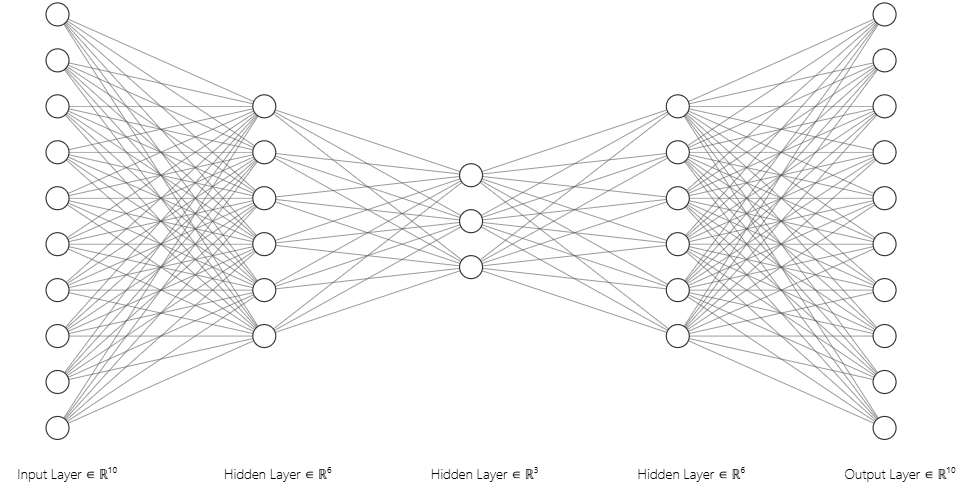

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

## AUTO-ENCODER (the whole autoencoder)
AE = Sequential(name = "Auto-Encoder Architecture")
AE.add(Input(shape=(10,)))             ## [encoder] input layer with # of variables as neurons
AE.add(Dense(6, activation='relu'))    ## [encoder] hidden layer
AE.add(Dense(3, activation='relu'))    ## [encoder-decoder] latent space
AE.add(Dense(6, activation='relu'))    ## [decoder] hidden layer
AE.add(Dense(10, activation='linear')) ## [decoder] output layer

## LOSS FUNCTION: MSE
AE.compile(optimizer='adam', loss='mse')

## SUMMARY
AE.summary()

## FIT
## AE.fit(X, X, epochs = 100, validation_split = 0.2, callbacks = [early_stop])

## PREDICT
## X_reconstructed = AE.predict(X)
## X and X_reconstructed. Say that obs 10 has a huge reconstruction error (likely anomaly)

Model: "Auto-Encoder Architecture"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │            70 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181 (724.00 B)

 Trainable params: 181 (724.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
## what if you want h (encoder NN) and f (decoder) separately

from tensorflow.keras.models import Model ## can combine different neural nets

## ENCODER (h)
encoder = Sequential(name = "Encoder")
encoder.add(Input(shape=(10,)))
encoder.add(Dense(6, activation='relu'))
encoder.add(Dense(3, activation='relu'))  ## latent space

## DECODER (f)
decoder = Sequential(name = "Decoder")
decoder.add(Input(shape=(3,)))
decoder.add(Dense(6, activation='relu'))
decoder.add(Dense(10, activation='linear'))

## Combine the two
AE1 = Model(inputs = encoder.inputs, outputs = decoder(encoder.outputs))

## compile
AE1.compile(optimizer='adam', loss='mse')

## summary
AE1.summary()

## fit
## AE1.fit(X, X, epochs = 100, validation_split = 0.2, callbacks = [early

Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Sequential)            │ (None, 10)             │            94 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181 (724.00 B)

 Trainable params: 181 (724.00 B)

 Non-trainable params: 0 (0.00 B)

---

# 2. Architecture and bottleneck

A simple autoencoder looks like:

**Input → Encoder → Latent Space → Decoder → Reconstruction**

The input and output layers have the same number of variables because the goal is to reconstruct the original input.

## Practice 2A

Suppose a dataset has 12 input variables and an autoencoder uses:

- Input: 12
- Hidden: 8
- Latent: 3
- Hidden: 8
- Output: 12

Answer:

1. What is the bottleneck dimension?
2. Why must the output layer have 12 neurons?


**Your response here:**  
1.  3-dimensional latent space
2.  We are predicting X so we need the same dimension

## Practice 2B: Count parameters

Suppose an autoencoder has:

- Input: 6
- Hidden: 4
- Latent: 2
- Hidden: 4
- Output: 6

How many trainable parameters are there in total?

In [ ]:

# TODO
params_input_hidden = 6*4 + 4
params_hidden_latent = 4*2 + 2
params_latent_hidden = 2*4 + 4
params_hidden_output = 4*6 + 6
total_params = params_input_hidden + params_hidden_latent + params_latent_hidden + params_hidden_output

print("Total parameters =", total_params)

Total parameters = 80


---

# 3. Reconstruction error

An autoencoder tries to reproduce the input rather than predict a separate target.

A common loss for numeric inputs is **mean squared error (MSE)**:

$
MSE = \frac{1}{n}\sum_{i=1}^{n}(x_i - \hat{x}_i)^2
$

## Practice 3A

Suppose for one observation:

- original: `[4.0, 2.0, 6.0]`
- reconstructed: `[3.5, 2.2, 5.4]`

Compute the observation-level MSE.

In [ ]:
## every obs has p-variables
## the reconstruction error is the MSE value by each row
## example, say that we have p = 3 (sqft, # rooms, dist)
x_true = np.array([4.0, 2.0, 6.0])
x_hat = np.array([3.5, 2.2, 5.4])

# TODO
obs_mse = np.mean((x_true - x_hat)**2) ## an mse by obs

print("Observation MSE =", obs_mse)

## if I have a whole data X
## we need MSE calculated by row (reconstruction error)

Observation MSE = 0.21666666666666656


## Practice 3B

If an observation has a much larger reconstruction error than the others, what might that suggest in an anomaly-detection setting?

**Your response here:**  





---

# 4. Tiny encoder-decoder example by hand

In [ ]:

# One observation with 4 features
x = np.array([8.0, 3.0, 6.0, 1.0])

# Encoder: 4 -> 2
W_enc = np.array([
    [0.20, 0.10],
    [0.40, 0.30],
    [0.10, 0.50],
    [0.30, 0.20]
])
b_enc = np.array([0.1, -0.2])

In [ ]:
# Decoder: 2 -> 4
W_dec = np.array([
    [0.50, 0.20, 0.30, 0.10],
    [0.10, 0.40, 0.20, 0.30]
])
b_dec = np.array([0.0, 0.1, -0.1, 0.2])

print("Ready.")

Ready.


## Practice 4A

Use the encoder

$
z = xW_{enc} + b_{enc}
$

Compute the 2-dimensional latent vector `z`.

In [ ]:
# TODO
z = None
print("Latent vector z =", z)

Latent vector z = None


In [ ]:
# TODO
## add relu activation

a = None
print("Activation a =", a)

Activation a = None


## Practice 4B

Use the decoder

$
\hat{x} = aW_{dec} + b_{dec}
$

Compute the reconstructed vector.

In [ ]:
# TODO
x_reconstructed = None

print("Reconstructed x =", x_reconstructed)

Reconstructed x = None


## Practice 4C

Compute the reconstruction MSE between `x` and `x_reconstructed`.

In [ ]:
# TODO
tiny_recon_mse = None
print("Tiny reconstruction MSE =", tiny_recon_mse)

Tiny reconstruction MSE = None


---

# 5. Example

Let's fit an autoencoder to CRM data with anomalies

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/martinwg/ISA630/refs/heads/master/data/customer_anomaly_data.csv')


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["is_anomaly"])
y = df["is_anomaly"]

# Scale using only normal training data
scaler = StandardScaler()
X = scaler.fit_transform(X)

print(X.shape,)

(1000, 6)


## Practice 5A

Why might an autoencoder be useful on this type of business dataset, even though we do not have a target variable?

**Your response here:**  
-

Build this structure:

- input dimension = 5
- encoder hidden layer = 3 neurons, ReLU
- latent layer = 2 neurons, linear
- decoder hidden layer = 3 neurons, ReLU
- output layer = 5 neurons, linear

Compile with:
- optimizer = `"adam"`
- loss = `"mse"`

## Practice 6C

Plot training loss and validation loss.

## Practice 6D

Why does forcing the model through a latent layer with only 2 neurons create compression?

**Your response here:**  





---

# 7. Latent space and dimension reduction

## Practice 7A

Create an encoder model that maps the original inputs to the latent layer, then compute the latent representation for the test data.

## Practice 7B

Make a scatter plot of the two latent dimensions.

## Practice 7C

How is this related to dimension reduction?

**Your response here:**  
-

---

# 8. Reconstruction error as an anomaly score

A common business use of autoencoders is **anomaly detection**.

Idea:
- train on mostly typical observations
- unusual observations reconstruct poorly
- larger reconstruction error can be used as an anomaly score

## Practice 8A

For each observation in `X_test_scaled`, compute

$
\text{MSE}_i = \frac{1}{p}\sum_{j=1}^{p}(x_{ij} - \hat{x}_{ij})^2
$

## Practice 8B

Display the 10 observations with the highest reconstruction error.

## Practice 8C

Give one reason why a large reconstruction error might flag an unusual customer profile.

**Your response here:**  


